Preparation

In [7]:
# %pip install mediapipe opencv-python numpy

In [ ]:
# import urllib.request

# url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
# urllib.request.urlretrieve(url, "face_landmarker.task")

('face_landmarker.task', <http.client.HTTPMessage at 0x236271a2490>)

In [2]:
import cv2
import os
import numpy as np
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python.vision import PoseLandmark

In [4]:
#@markdown We implemented some functions to visualize the face landmark detection results. <br/> Run the following cell to activate the functions.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize.
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

Make Detections

Camera

In [8]:
#VIDEO FEED
# Create an FaceLandmarker object
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode = vision.RunningMode.IMAGE,
    min_face_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1
)

cap = cv2.VideoCapture(0)

with mp.tasks.vision.FaceLandmarker.create_from_options(options) as landmarker: 
    while cap.isOpened():
        ret, frame = cap.read()
        #Recolor image to RGB
        image = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        # Convert to mp.Image
        image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
        # Make detection
        detection_result = landmarker.detect(image)
        # Extract landmarks
        try:
            landmarks = detection_result.face_landmarks[0]
            # print(landmarks)
        except:
            pass

        # Render detections
        if detection_result.face_landmarks:
            for face_landmarks in detection_result.face_landmarks:
                annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
        
        cv2.imshow("Result", cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
    
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

Image

In [5]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1,
                                       min_face_detection_confidence=0.5,
                                       min_tracking_confidence=0.5)

with mp.tasks.vision.FaceLandmarker.create_from_options(options) as landmarker:
    # STEP 3: Load the input image.
    image = mp.Image.create_from_file("emotion_dataset_split_70_15_15/test/anger/test_image0000343.jpg")

    # STEP 4: Detect face landmarks from the input image.
    detection_result = landmarker.detect(image)

    # STEP 5: Process the detection result. In this case, visualize it.
    annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
cv2.imshow("Result", cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
cv2.waitKey(0)
cv2.destroyAllWindows()

In [13]:
for face_blendshapes_category in detection_result.face_blendshapes[0]:
  print(face_blendshapes_category)


Category(index=0, score=4.837017968384316e-06, display_name=None, category_name='_neutral')
Category(index=1, score=0.03223831579089165, display_name=None, category_name='browDownLeft')
Category(index=2, score=0.08040720224380493, display_name=None, category_name='browDownRight')
Category(index=3, score=0.00089088553795591, display_name=None, category_name='browInnerUp')
Category(index=4, score=0.12650826573371887, display_name=None, category_name='browOuterUpLeft')
Category(index=5, score=0.029723038896918297, display_name=None, category_name='browOuterUpRight')
Category(index=6, score=0.00022931686544325203, display_name=None, category_name='cheekPuff')
Category(index=7, score=2.6898047167378536e-07, display_name=None, category_name='cheekSquintLeft')
Category(index=8, score=8.510693874086428e-07, display_name=None, category_name='cheekSquintRight')
Category(index=9, score=0.024847490713000298, display_name=None, category_name='eyeBlinkLeft')
Category(index=10, score=0.02646270208060

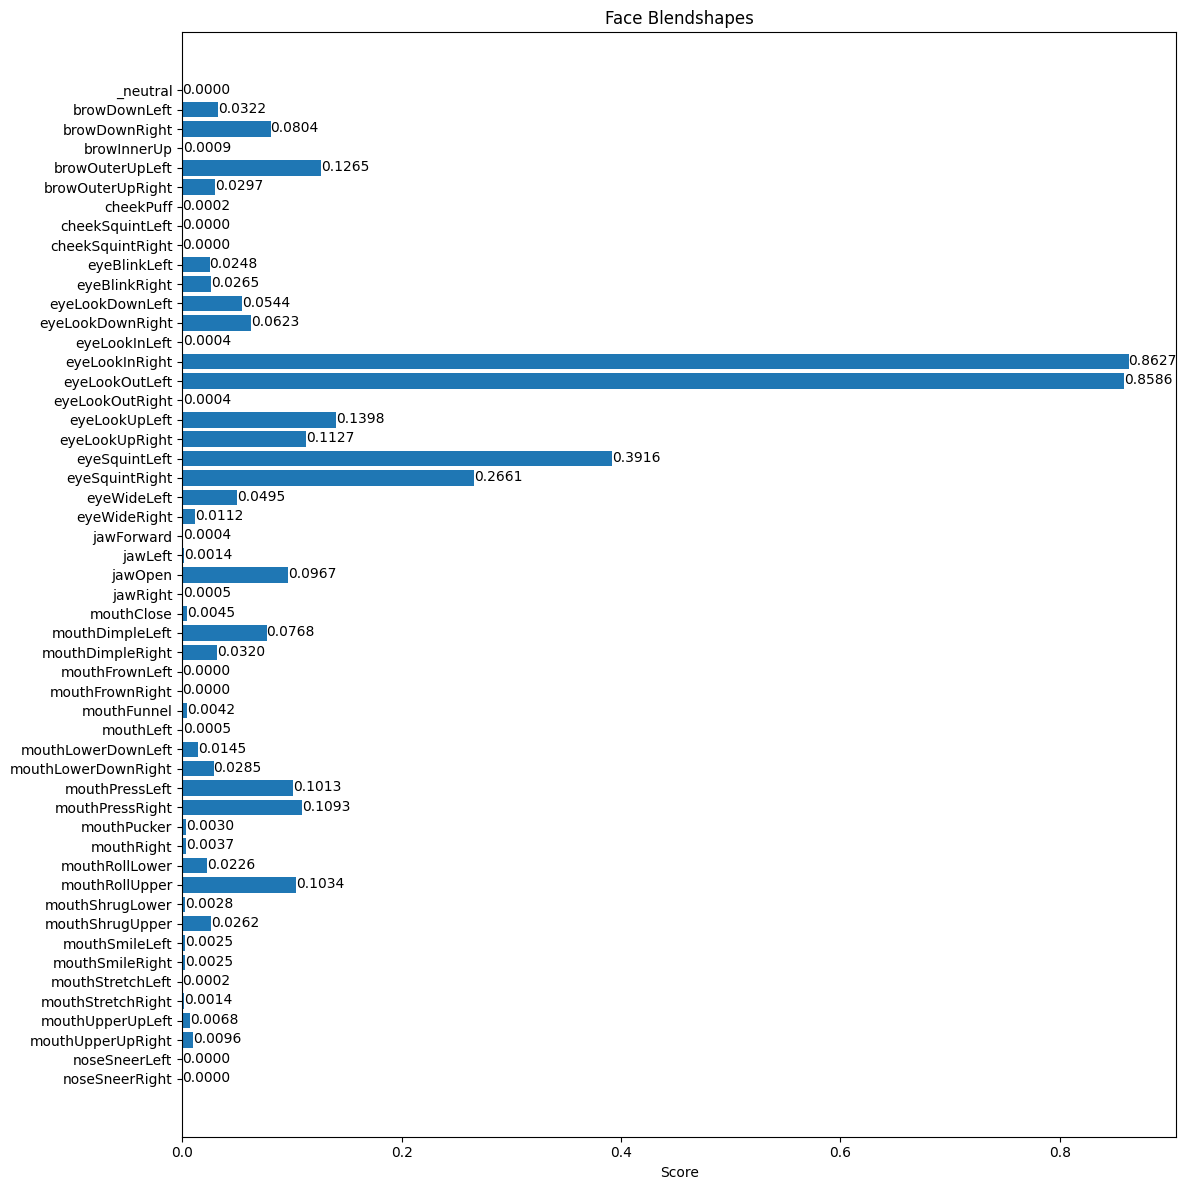

In [6]:
plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

Video

In [ ]:
# Create an PoseLandmarker object
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode = vision.RunningMode.IMAGE,
    min_face_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1
)
cap = cv2.VideoCapture("emotion_dataset_split_70_15_15/video/thaygiaoba.mp4")


with mp.tasks.vision.FaceLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        # Recolor image to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Convert to mp.Image
        image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
        # Make detection
        detection_result = landmarker.detect(image)
        # # Extract landmarks
        # try:
        #     landmarks = detection_result.face_landmarks[0]
        #     # print(landmarks)
        # except:
        #     pass
        #Visualize
        if detection_result.face_landmarks:
            annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)

        cv2.imshow("Result", cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
    
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows() 